# Importing all the module first

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import numpy as np
warnings.filterwarnings('ignore')

## Defining the style 

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option('display.max_columns',100)
pd.set_option('display.float_format',lambda x:f'{x:.3f}') #for changing large decimal point upto 3 after(eg. 3.57575=3.575)

## Loading the data


In [ ]:
train=pd.read_csv("../data/train.csv")
test=pd.read_csv("../data/test.csv")

## Checking the basic details of data

In [ ]:
print(f" train shape is {train.shape}")
print(f"test shape is {test.shape}")
print(f"top 5 data of train data\n{train.head()}")
print(f"print which data are empty{train.isnull().sum()}")


 train shape is (1460, 81)
test shape is (1459, 80)
top 5 data of train data
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL       65.000     8450   Pave   NaN      Reg   
1   2          20       RL       80.000     9600   Pave   NaN      Reg   
2   3          60       RL       68.000    11250   Pave   NaN      IR1   
3   4          70       RL       60.000     9550   Pave   NaN      IR1   
4   5          60       RL       84.000    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
1         Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
2         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
3         Lvl    AllPub    Corner       Gtl      Crawfor       Norm   
4         Lvl    AllPub       FR2       Gtl      NoRidge       Norm   

  Condition2 BldgType HouseStyle  OverallQual  Over

## Lets visualize the data


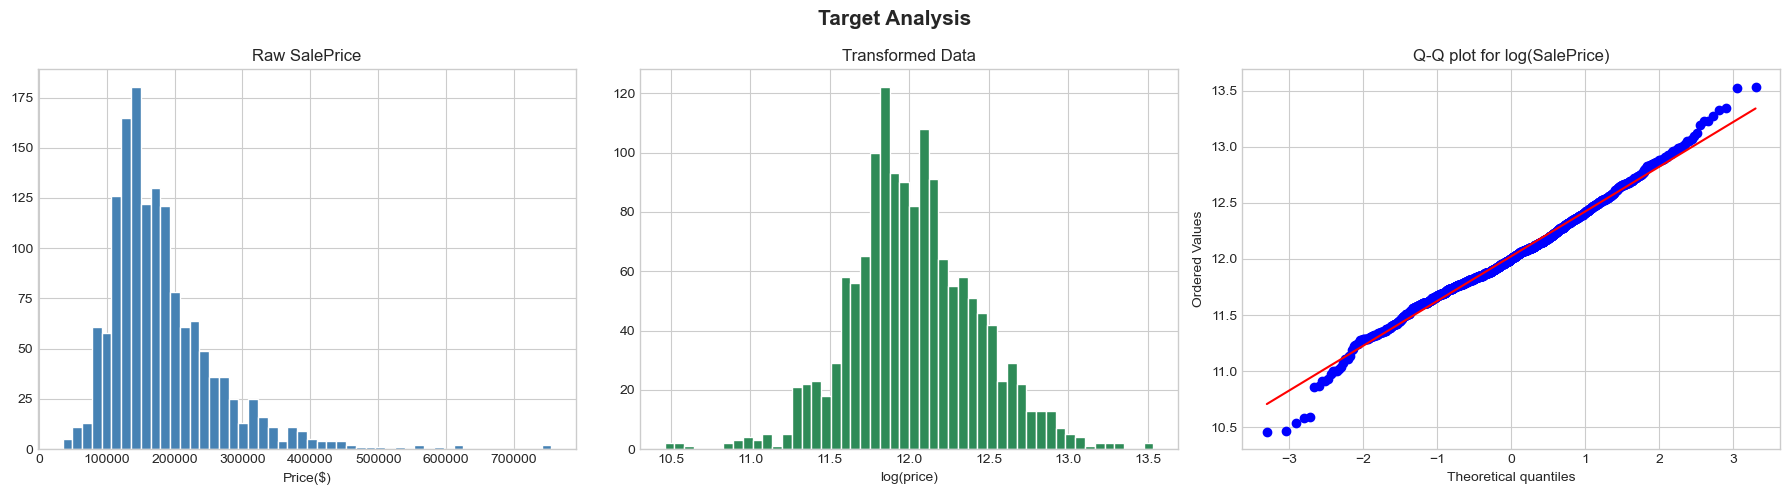

In [ ]:
fig,axes=plt.subplots(1,3, figsize=(18,5))
fig.suptitle('Target Analysis',fontsize=15, fontweight='bold')

# I use axes[0] for displaying the raw saleprice of house
axes[0].hist(train['SalePrice'],bins=50,color='steelblue',edgecolor='white')
axes[0].set_title("Raw SalePrice")
axes[0].set_xlabel("Price($)")

# I use axes[1] for displaying the log transformed saleprice of house
log_price=np.log1p(train['SalePrice'])
axes[1].hist(log_price,bins=50,color='seagreen', edgecolor='white')
axes[1].set_title("Transformed Data")
axes[1].set_xlabel("log(price)")

# I use axes[2] for displaying the distribution pattern of house saleprice
stats.probplot(log_price,dist='norm',plot=axes[2])
axes[2].set_title("Q-Q plot for log(SalePrice)")

plt.tight_layout()
plt.savefig('../pictures/target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## In above fig we convert the alpha distribution into normal distribution fig 3-: show there are some skewed data 

## Checking the skewness of data

In [ ]:
print(f"skewness before log(SalePrice) is {train['SalePrice'].skew()} we want near 0")
print(f"skewness after log(SalePrice) is {log_price.skew():.3f}")

skewness before log(SalePrice) is 1.8828757597682129 we want near 0
skewness after log(SalePrice) is 0.121


you can clearly see that our value is much more linear after the log_transform


## Checking the missing values


In [ ]:
missing=train.isnull().sum()
missng=missing[missing>0].sort_values(ascending=False)
missing_pct=(missing/len(train)*100).round(2)
missing_df=pd.DataFrame({
    'missing_count': missing,
    'missing_pct':missing_pct
})
print("\n── Top 20 columns with missing values ──")
print(missing_df.head(20))


── Top 20 columns with missing values ──
              missing_count  missing_pct
Id                        0        0.000
MSSubClass                0        0.000
MSZoning                  0        0.000
LotFrontage             259       17.740
LotArea                   0        0.000
Street                    0        0.000
Alley                  1369       93.770
LotShape                  0        0.000
LandContour               0        0.000
Utilities                 0        0.000
LotConfig                 0        0.000
LandSlope                 0        0.000
Neighborhood              0        0.000
Condition1                0        0.000
Condition2                0        0.000
BldgType                  0        0.000
HouseStyle                0        0.000
OverallQual               0        0.000
OverallCond               0        0.000
YearBuilt                 0        0.000


## Barploting the missing value


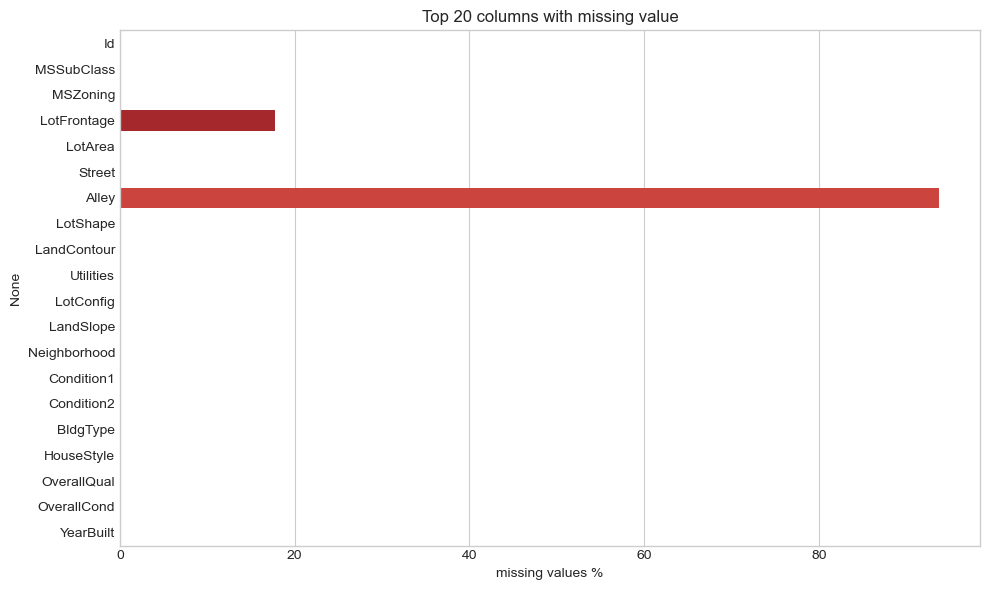

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=missing_pct.head(20).values,
            y=missing_pct.head(20).index,
            palette="Reds_r"
           )
plt.title("Top 20 columns with missing value")
plt.xlabel("missing values %")
plt.tight_layout()
plt.savefig("../pictures/missing_value.png",dpi=150,bbox_inches='tight')
plt.show()

## finding the correlation of columns with Saleprice

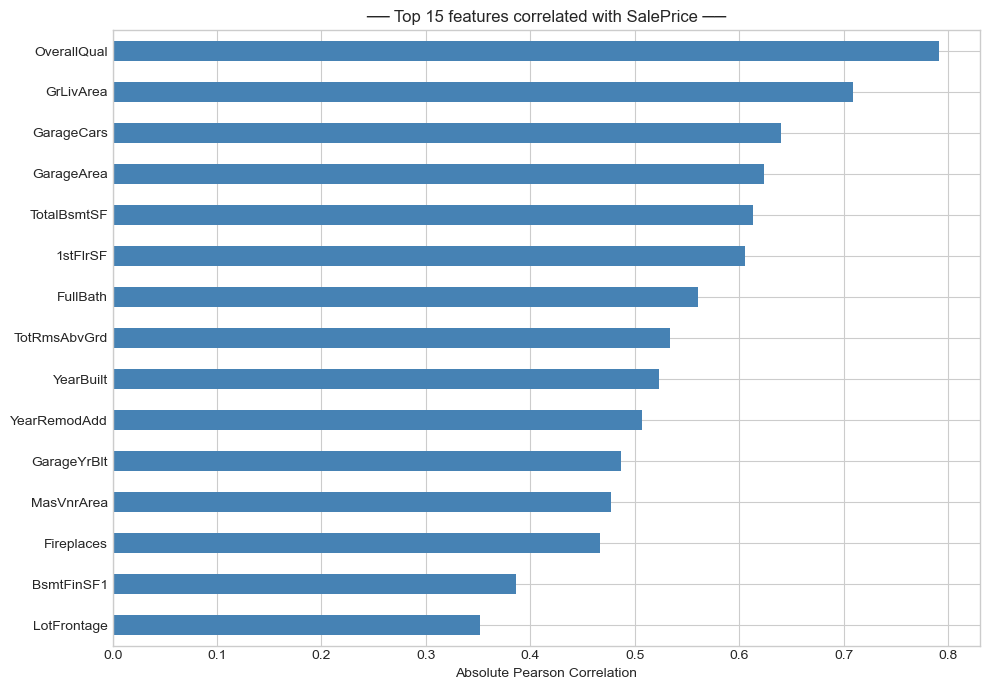

In [ ]:
numeric_cols=train.select_dtypes(include=[np.number]).columns.tolist()
correlations=train[numeric_cols].corr()['SalePrice'].drop('SalePrice')
correlations=correlations.abs().sort_values(ascending=False)
plt.figure(figsize=(10, 7))
correlations.head(15).plot(kind='barh', color='steelblue')
plt.title("── Top 15 features correlated with SalePrice ──")
plt.xlabel("Absolute Pearson Correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../pictures/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## Now we know the main columns which are the key features columns for SalePrice

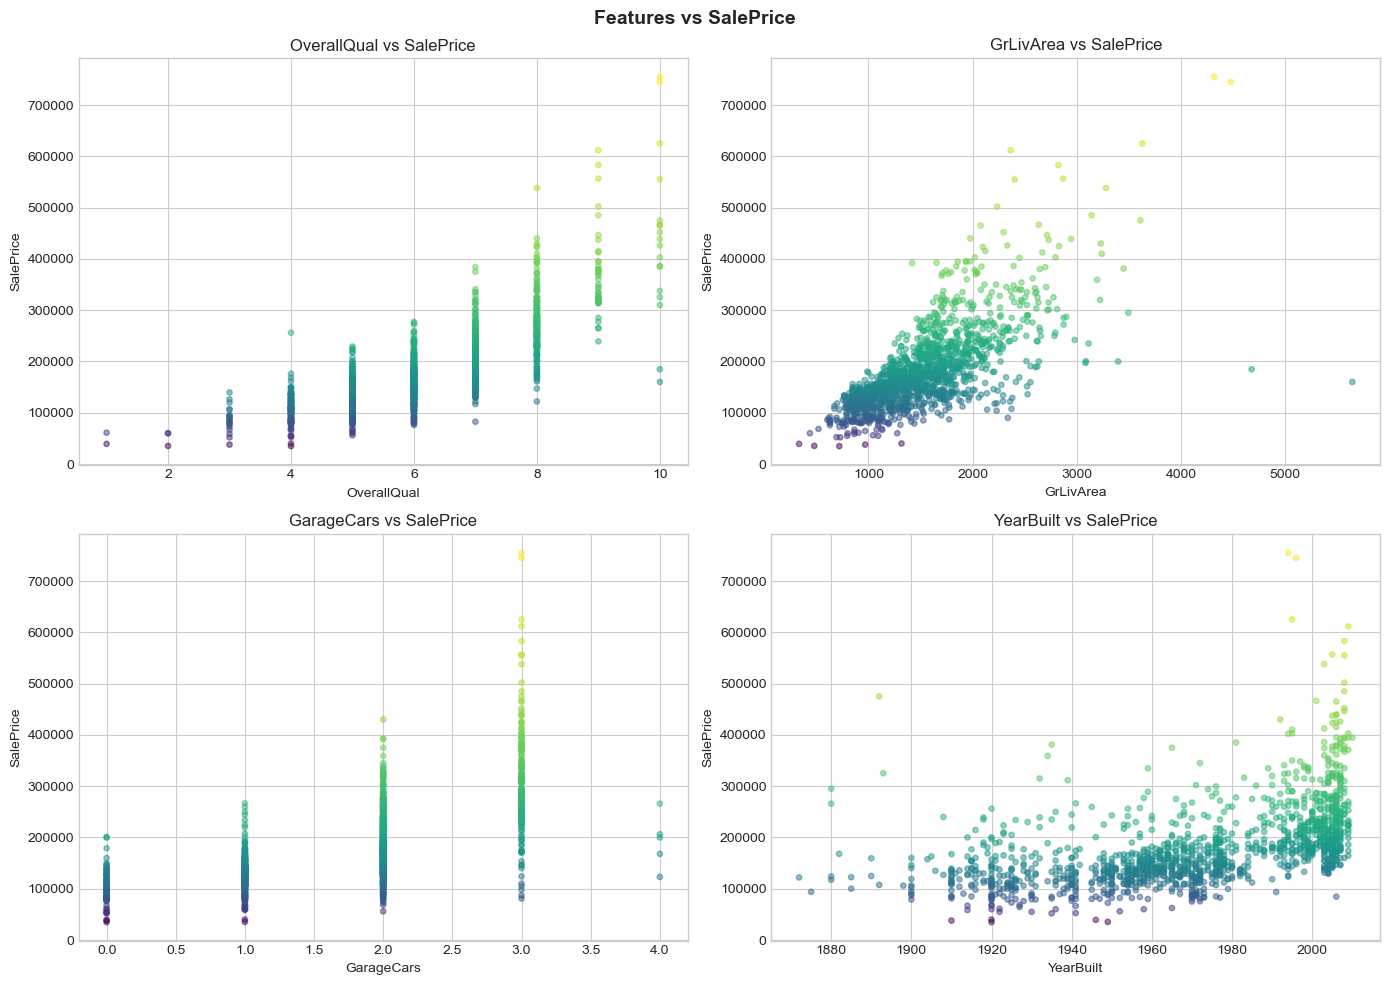

In [ ]:
top_features=[
    'OverallQual','GrLivArea','GarageCars','YearBuilt'
]
fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle("Features vs SalePrice", fontsize=14,fontweight='bold')

for ax, feat in zip(axes.flatten(), top_features):
    ax.scatter(train[feat], train['SalePrice'], alpha=0.5,
               c=np.log1p(train['SalePrice']), cmap='viridis', s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice')
plt.tight_layout()
plt.savefig("../pictures/Topfeature_relation.png",dpi=150, bbox_inches="tight")
plt.show()

# check how many string data are present before changing into integer 

In [ ]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumber of categorical features: {len(cat_cols)}")
print("\nCategories per feature:")
for col in sorted(cat_cols):
    print(f"  {col:20s}: {train[col].nunique()} unique values")

print("\n── Data type breakdown ──")
print(train.dtypes.value_counts())

print("\n── Basic stats for SalePrice ──")
print(train['SalePrice'].describe())



Number of categorical features: 43

Categories per feature:
  Alley               : 2 unique values
  BldgType            : 5 unique values
  BsmtCond            : 4 unique values
  BsmtExposure        : 4 unique values
  BsmtFinType1        : 6 unique values
  BsmtFinType2        : 6 unique values
  BsmtQual            : 4 unique values
  CentralAir          : 2 unique values
  Condition1          : 9 unique values
  Condition2          : 8 unique values
  Electrical          : 5 unique values
  ExterCond           : 5 unique values
  ExterQual           : 4 unique values
  Exterior1st         : 15 unique values
  Exterior2nd         : 16 unique values
  Fence               : 4 unique values
  FireplaceQu         : 5 unique values
  Foundation          : 6 unique values
  Functional          : 7 unique values
  GarageCond          : 5 unique values
  GarageFinish        : 3 unique values
  GarageQual          : 5 unique values
  GarageType          : 6 unique values
  Heating        

# now convert into integer 

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
# Create encoder
le = LabelEncoder()

# Apply encoding to all object/string columns
for col in train.columns:
    if train[col].dtype == 'object' or train[col].dtype=='NaN' :
        train[col] = le.fit_transform(train[col].astype(str))

for col in test.columns:
    if test[col].dtype == 'object' or test[col].dtype=='NaN' :
        test[col] = le.fit_transform(test[col].astype(str))
    if test[col].isnull().any()==True:
        test[col]=test[col].fillna(test[col].mean())
print(train.head())

   Id  MSSubClass  MSZoning  LotFrontage  LotArea  Street  Alley  LotShape  \
0   1          60         3       65.000     8450       1      2         3   
1   2          20         3       80.000     9600       1      2         3   
2   3          60         3       68.000    11250       1      2         0   
3   4          70         3       60.000     9550       1      2         0   
4   5          60         3       84.000    14260       1      2         0   

   LandContour  Utilities  LotConfig  LandSlope  Neighborhood  Condition1  \
0            3          0          4          0             5           2   
1            3          0          2          0            24           1   
2            3          0          4          0             5           2   
3            3          0          0          0             6           2   
4            3          0          2          0            15           2   

   Condition2  BldgType  HouseStyle  OverallQual  OverallCond  YearB

# Now no data are string 

In [ ]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = train.select_dtypes(exclude=['object']).columns.tolist()
print(f"\nNumber of categorical features: {len(cat_cols)}")
print("\nCategories per feature:")
for col in sorted(cat_cols):
    print(f"  {col:20s}: {train[col].nunique()} unique values")

print("\n── Data type breakdown ──")
print(train.dtypes.value_counts())

print("\n── Basic stats for SalePrice ──")
print(train['SalePrice'].describe())
nulls=train.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False))



Number of categorical features: 0

Categories per feature:

── Data type breakdown ──
int64      78
float64     3
Name: count, dtype: int64

── Basic stats for SalePrice ──
count     1460.000
mean    180921.196
std      79442.503
min      34900.000
25%     129975.000
50%     163000.000
75%     214000.000
max     755000.000
Name: SalePrice, dtype: float64
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64


# Fill some of null data as 0 because Nan

In [ ]:
#our LoTFrontage ,GarageyrBlt,masvnrArea are null which also means there isn't any lotFrontage area so we fill with respective value
train['LotFrontage']= train['LotFrontage'].fillna(0)
train['GarageYrBlt']=train['GarageYrBlt'].fillna(train['GarageYrBlt'].mean())
train['MasVnrArea']=train['MasVnrArea'].fillna(0)

test['LotFrontage']= test['LotFrontage'].fillna(0)
test['GarageYrBlt']=test['GarageYrBlt'].fillna(train['GarageYrBlt'].mean())
test['MasVnrArea']=test['MasVnrArea'].fillna(0)

#

# Define a model to execute


In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
X=train.drop('SalePrice',axis=1)
y=log_price

##  I have used log_transform so also need to convert back to original


In [ ]:
model=LinearRegression()
model.fit(X,y)
log_pred=model.predict(test)
predictions= np.expm1(log_pred)
print(predictions)


[125895.28252147 169233.00694146 178894.43059807 ... 167435.98976071
 125851.52261226 256798.59230926]


# I use this to save my model for future purpose without running all the code 

In [ ]:
import joblib
joblib.dump(model,"../model/house_price_predictor.pkl")

['../model/house_price_pridictor.pkl']

# Saving prediction file 


In [37]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": predictions
})

submission.to_csv(
    "../prediction/submission.csv",
    index=False
)